In [52]:
import torch
from torchvision import datasets, transforms
data_dir = "./data"


transform = transforms.ToTensor()
trainset = datasets.MNIST(
    root=data_dir, 
    train=True,
    download=True,
    transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [53]:
all_images_train = torch.stack([trainset[i][0] for i in range(len(trainset))])
all_images_test = torch.stack([testset[i][0] for i in range(len(testset))])

#Calculate mean and std of the training and test datasets, for normalizaton

mean_train = all_images_train.mean().item()
std_train = all_images_train.std().item()
print(f"all_images_train - Media: {mean_train:.4f}, Std: {std_train:.4f}")

mean_test = all_images_test.mean().item()
std_test = all_images_test.std().item()
print(f"all_images_test - Media: {mean_test:.4f}, Std: {std_test:.4f}")

all_images_train - Media: 0.1307, Std: 0.3081
all_images_test - Media: 0.1325, Std: 0.3105


# Loading data

Loading data:
    - test
    - seed

Using compose to transform the data:
    . To tensor: 
        to convert the datasets into a tensor
    . Normalization
        

In [54]:

from torchvision import datasets, transforms

data_dir = "./data"


transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((mean_test,), (std_test,))
    ])

trainset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [55]:
def images_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    images =  torch.stack([dataset[i][0] for i in range(len(dataset))])
    return images.numpy()


def labels_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])
    return labels.numpy()

In [56]:
test_images = images_extractor(testset)
test_labels = labels_extractor(testset)
test_images_cnn = test_images.reshape((-1, 28, 28, 1))

# Statistics 

## Mean and STD are suppose to be 0 an 1 since they are normalized. 

# Expected results after trainng

In [57]:

import numpy as np

print(f"mean = {test_images.mean():.4f}, std = {test_images.std():.4f}")

unique_t, counts_t = np.unique(test_labels, return_counts=True)

print("\nDistribution in TEST:")
for d, c in zip(unique_t, counts_t):
    print(f"  Digit {d}: {c} images")


mean = -0.0000, std = 1.0000

Distribution in TEST:
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


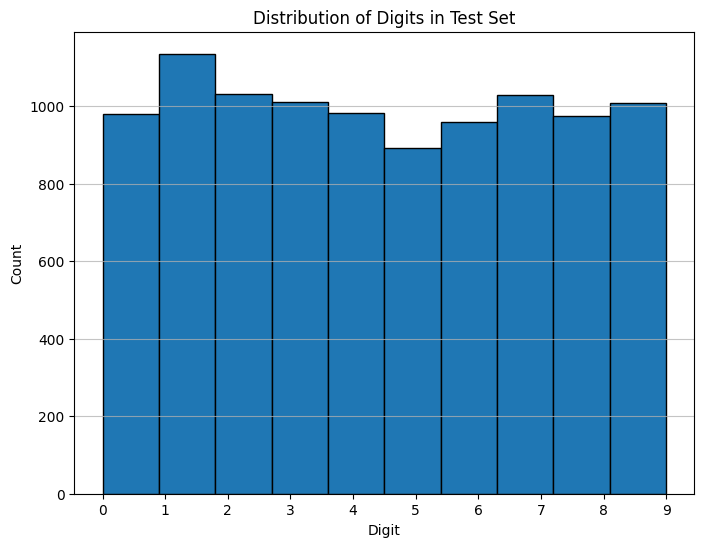

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(test_labels, edgecolor='black')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits in Test Set')
plt.grid(axis='y', alpha=0.75)
plt.savefig('../output/digit_distribution.png', dpi=150)
plt.show()


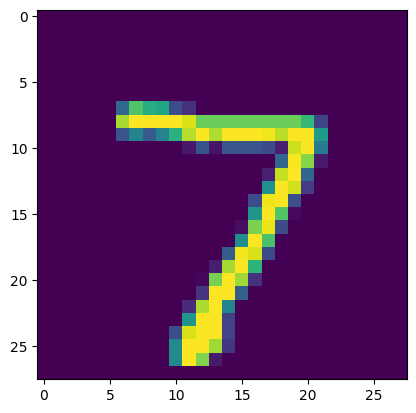

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(test_images[0,0])
plt.show()

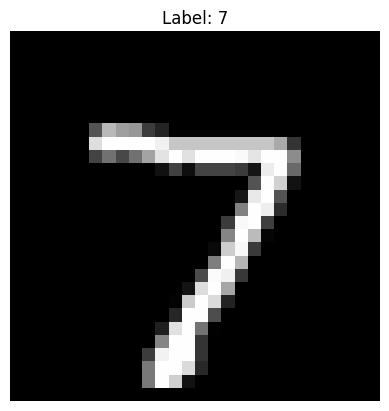

In [66]:
import matplotlib.pyplot as plt

plt.imshow(test_images[0, 0], cmap='gray')
plt.title(f"Label: {test_labels[0]}")
plt.axis('off')
plt.savefig(f'../output/sample_image_label_{test_labels[0]}.png', dpi=150)
plt.show()


(10000, 1, 28, 28)


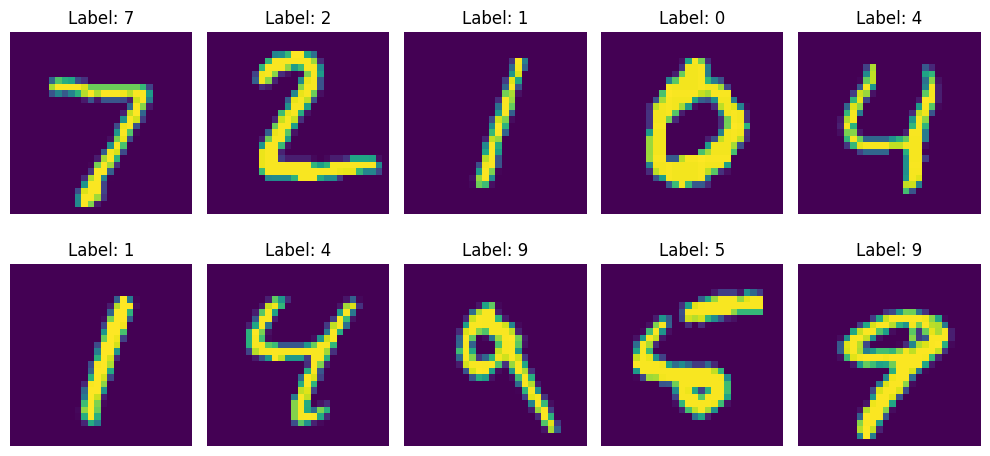

In [ ]:
import matplotlib.pyplot as plt

print(test_images.shape)   

# test_images' shape is (N, 1, 28, 28)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = test_images[i, 0] if test_images.ndim == 4 else test_images[i]
    img_display = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f"Label: {test_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images.png', dpi=150)
plt.show()

# Modeling 
